# 01 — Génération et exploration de MauriPay-M

Ce notebook génère automatiquement **100 000 transactions** reproductibles (`seed=42`), puis explore les canaux, les wilayas, les montants, le Ramadan et les anomalies injectées. Toutes les figures sont aussi sauvegardées dans `notebooks/outputs/01_generation/`.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 110})

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'backend' / 'src' / 'mauripay').exists():
            return candidate
    raise RuntimeError('Racine MauriPay-Analytics introuvable')

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / 'backend' / 'src'))
DATA_DIR = ROOT / 'data' / 'generated'
OUTPUT_DIR = ROOT / 'notebooks' / 'outputs' / '01_generation'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)
print(f'Racine : {ROOT}')

Racine : D:\mauripay-analytics


## Génération de MauriPay-M
Le fichier est créé lors de la première exécution. Les exécutions suivantes le rechargent afin d'accélérer le notebook. Supprimer le fichier permet de reproduire exactement la génération avec la même seed.

In [2]:
from mauripay.detection.io import load_table
from mauripay.synthetic.exporters import export_transactions
from mauripay.synthetic.generator import generate_transactions

DATA_PATH = DATA_DIR / 'mauripay_m_notebook_100k.parquet'
if not DATA_PATH.exists():
    print('Génération de 100 000 transactions...')
    transactions = generate_transactions(
        rows=100_000,
        seed=SEED,
        anomaly_rate=0.02,
        tontine_rate=0.001,
        structuring_rate=0.003,
        high_frequency_rate=0.002,
    )
    export_transactions(transactions, DATA_PATH)
    del transactions
else:
    print('Dataset reproductible déjà présent : rechargement.')

df = load_table(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['amount'] = pd.to_numeric(df['amount'])
df['is_anomaly'] = df['is_anomaly'].astype(str).str.lower().isin(['true', '1', 'yes'])
print(f'{len(df):,} lignes × {df.shape[1]} colonnes')
df.head(3)

Dataset reproductible déjà présent : rechargement.
100,000 lignes × 18 colonnes


,transaction_id,timestamp,sender_id,receiver_id,amount,currency,transaction_type,channel,operator,sender_wilaya,receiver_wilaya,status,fees,is_ramadan,bill_provider,origin_country,is_anomaly,anomaly_type
0,6024433e-9401-4dbe-8f22-99e66f35d82d,2026-02-25 20:27:54+00:00,ACC_00631,ACC_04807,44522.66,MRU,CASH_IN,USSD,Bamis Digital,Nouakchott-Sud,Hodh El Chargui,SUCCESS,320.89,True,,US,False,NONE
1,b8e81324-5e16-4e41-8fe7-137153791e09,2026-02-22 20:11:41+00:00,ACC_01207,ACC_03950,60949.98,MRU,TRANSFER,USSD,Masrvi,Dakhlet Nouadhibou,Trarza,SUCCESS,1068.99,True,,,False,NONE
2,0a9df1bc-3f78-446a-aed6-b0c6ae450dc0,2026-01-13 08:49:18+00:00,ACC_01292,ACC_04450,6827.48,MRU,BILL_PAY,USSD,Bankily,Nouakchott-Sud,Nouakchott-Ouest,SUCCESS,0.00,False,SOMELEC,,False,NONE


In [3]:
summary = pd.DataFrame({
    'indicateur': ['Transactions', 'Montant total (MRU)', 'Montant moyen (MRU)', 'Anomalies injectées'],
    'valeur': [len(df), df['amount'].sum(), df['amount'].mean(), int(df['is_anomaly'].sum())],
})
summary

,indicateur,valeur
0,Transactions,1.000000e+05
1,Montant total (MRU),3.154479e+09
2,Montant moyen (MRU),3.154479e+04
3,Anomalies injectées,7.691000e+03


## Répartition des canaux

,transactions,part_%
channel,,
USSD,71704,71.70
APP,23082,23.08
AGENT,5214,5.21


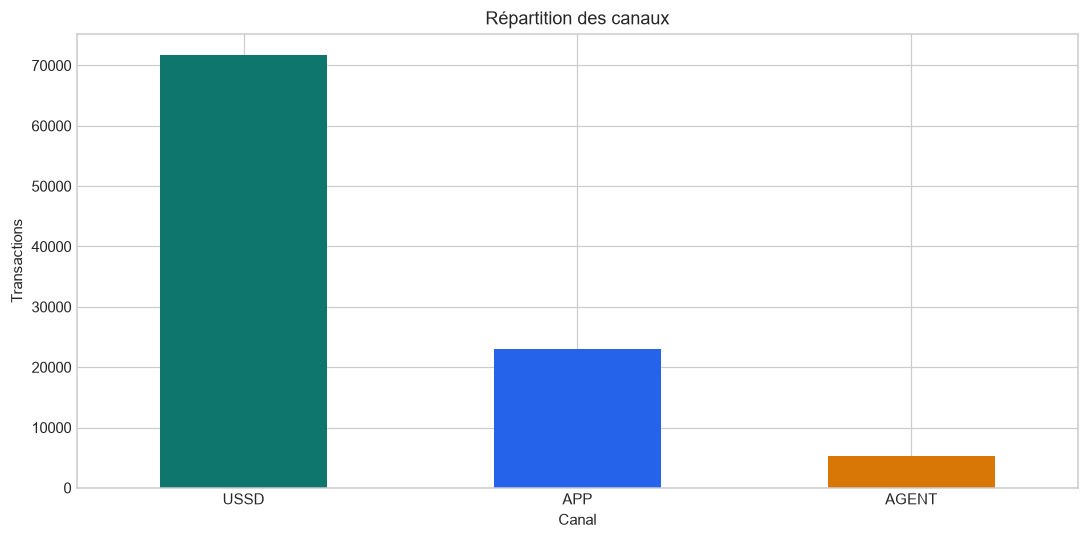

In [4]:
channel_counts = df['channel'].value_counts()
channel_table = pd.DataFrame({'transactions': channel_counts, 'part_%': (channel_counts / len(df) * 100).round(2)})
display(channel_table)
ax = channel_counts.plot.bar(color=['#0f766e', '#2563eb', '#d97706'], title='Répartition des canaux')
ax.set(xlabel='Canal', ylabel='Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'canaux.png', bbox_inches='tight')
plt.show()

## Répartition des wilayas
Les rôles expéditeur et destinataire sont agrégés pour obtenir le volume total d'activité par wilaya.

,transactions
Nouakchott-Ouest,39461
Nouakchott-Sud,39374
Nouakchott-Nord,37943
Dakhlet Nouadhibou,30843
Trarza,9376
Brakna,8505
Gorgol,6356
Assaba,5877
Hodh El Chargui,5516
Guidimakha,3837


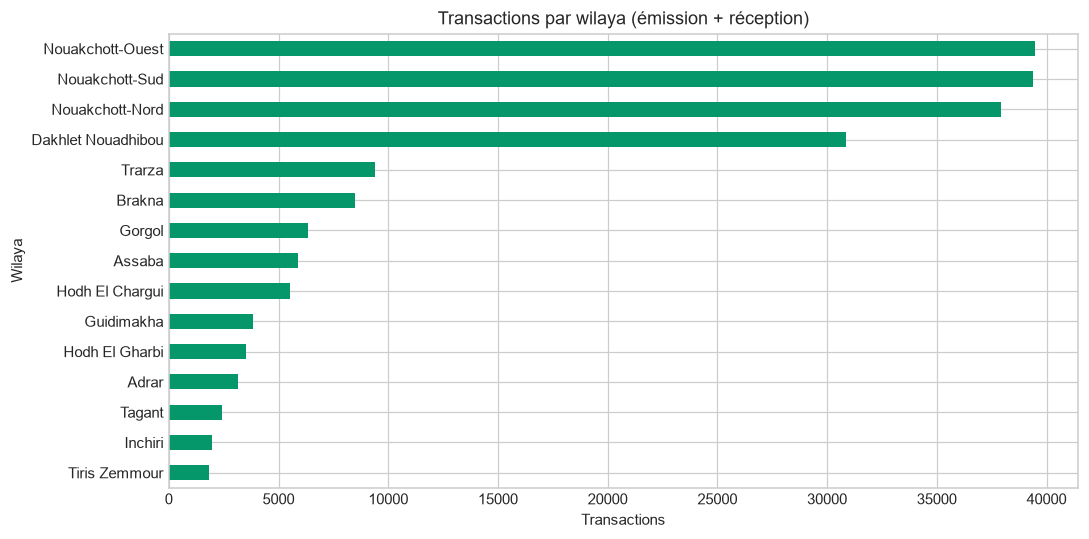

In [5]:
wilayas = pd.concat([df['sender_wilaya'], df['receiver_wilaya']], ignore_index=True)
wilaya_counts = wilayas.value_counts().sort_values()
display(wilaya_counts.sort_values(ascending=False).to_frame('transactions').head(15))
ax = wilaya_counts.plot.barh(color='#059669', title='Transactions par wilaya (émission + réception)')
ax.set(xlabel='Transactions', ylabel='Wilaya')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'wilayas.png', bbox_inches='tight')
plt.show()

## Distribution des montants

,montant_MRU
0.00,5.005000e+01
0.25,2.954825e+03
0.50,1.800376e+04
0.75,4.781678e+04
0.95,7.732711e+04
0.99,8.847684e+04
1.00,2.642063e+06


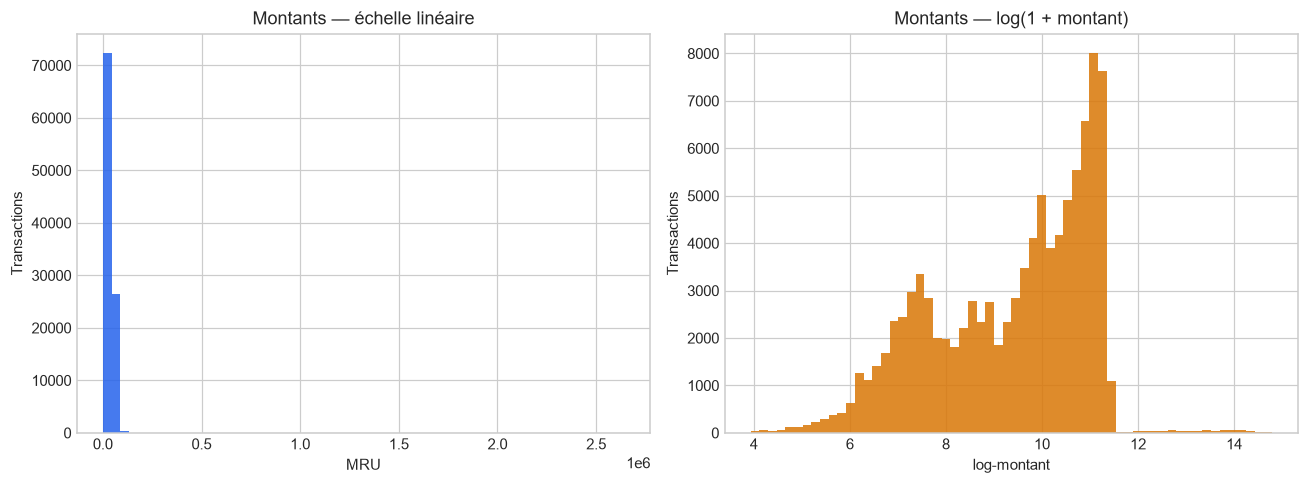

In [6]:
quantiles = df['amount'].quantile([0, .25, .5, .75, .95, .99, 1]).to_frame('montant_MRU')
display(quantiles)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df['amount'], bins=60, color='#2563eb', alpha=.85)
axes[0].set(title='Montants — échelle linéaire', xlabel='MRU', ylabel='Transactions')
axes[1].hist(np.log1p(df['amount']), bins=60, color='#d97706', alpha=.85)
axes[1].set(title='Montants — log(1 + montant)', xlabel='log-montant', ylabel='Transactions')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribution_montants.png', bbox_inches='tight')
plt.show()

## Pattern Ramadan

,transactions,montant_moyen
Hors Ramadan,44657,32038.86
Ramadan,55343,31146.11


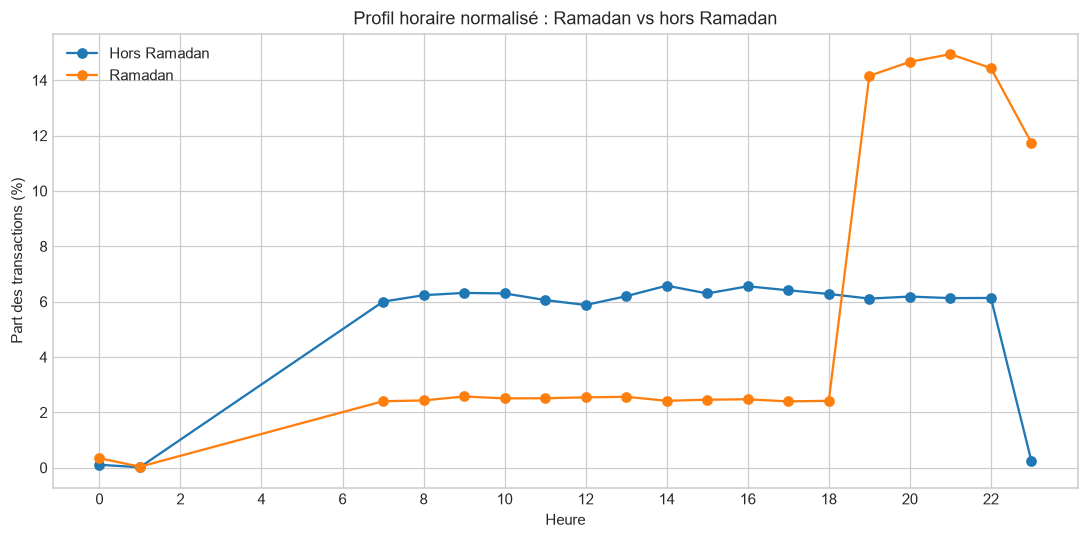

In [7]:
ramadan = df.groupby('is_ramadan').agg(transactions=('transaction_id', 'size'), montant_moyen=('amount', 'mean'))
ramadan.index = ['Hors Ramadan' if not bool(x) else 'Ramadan' for x in ramadan.index]
display(ramadan.round(2))
hourly = df.assign(hour=df['timestamp'].dt.hour).groupby(['is_ramadan', 'hour']).size().unstack(0, fill_value=0)
hourly.columns = ['Hors Ramadan' if not bool(x) else 'Ramadan' for x in hourly.columns]
hourly = hourly.div(hourly.sum(axis=0), axis=1) * 100
ax = hourly.plot(marker='o', title='Profil horaire normalisé : Ramadan vs hors Ramadan')
ax.set(xlabel='Heure', ylabel='Part des transactions (%)', xticks=range(0, 24, 2))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pattern_ramadan.png', bbox_inches='tight')
plt.show()

## Taux d'anomalies injectées

Taux final de lignes anormales : 7.69 %


,transactions
anomaly_type,
HIGH_FREQUENCY,4040
STRUCTURING,1780
HIGH_AMOUNT,960
OPERATOR_OUTAGE,534
UNUSUAL_LOCATION,377


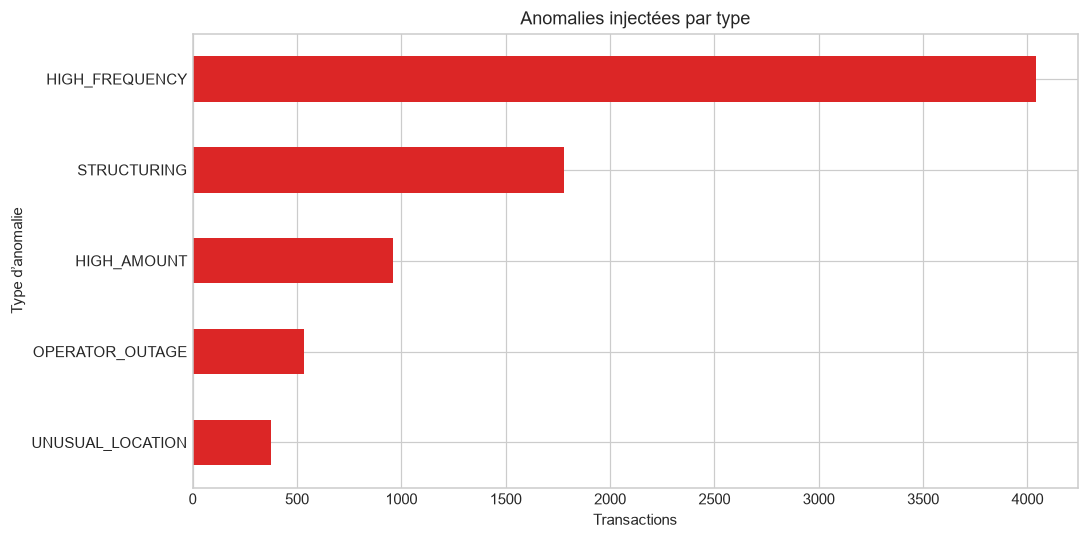

Figures exportées dans : D:\mauripay-analytics\notebooks\outputs\01_generation


In [8]:
anomaly_rate = df['is_anomaly'].mean() * 100
anomaly_counts = df.loc[df['is_anomaly'], 'anomaly_type'].value_counts().sort_values()
print(f'Taux final de lignes anormales : {anomaly_rate:.2f} %')
display(anomaly_counts.sort_values(ascending=False).to_frame('transactions'))
ax = anomaly_counts.plot.barh(color='#dc2626', title='Anomalies injectées par type')
ax.set(xlabel='Transactions', ylabel='Type d’anomalie')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'anomalies_injectees.png', bbox_inches='tight')
plt.show()
print(f'Figures exportées dans : {OUTPUT_DIR}')

## Conclusion
MauriPay-M reproduit des distributions métier non uniformes et injecte cinq familles d'anomalies. Le taux final de lignes anormales est supérieur au seul `anomaly_rate`, car les événements `STRUCTURING` et `HIGH_FREQUENCY` produisent plusieurs transactions.